In [9]:
# ENVIRONMENT SET UP
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import sklearn as sk
from collections import deque
import heapq
import random
import math

In [10]:
# FILE INCLUSION 
file_path = 'track_c_education/student_data.csv'
dataset = pd.read_csv(file_path)

In [11]:
dataset.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [30]:
dataset.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [31]:
#Print the shape (number of rows and columns)
print("Dataset Shape:", dataset.shape)

#Print the data types of each column
print("\nData Types:\n", dataset.dtypes)

#Check for missing values in every column
print("\nMissing Values:\n", dataset.isnull().sum())

Dataset Shape: (395, 33)

Data Types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing Values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures    

In [32]:
#Print the number of unique values in the target column
target_column = 'G3'
print(f"\nNumber of unique values in {target_column}:", dataset[target_column].nunique())
print("The unique values are:", dataset[target_column].unique())


Number of unique values in G3: 18
The unique values are: [ 6 10 15 11 19  9 12 14 16  5  8 17 18 13 20  7  0  4]


(The G3 is calculated out of 20)

In [33]:
# Tasks 6 & 7
class_counts = {}

# iterating through G3 column
for grade in dataset['G3']:
    if grade in class_counts:
        class_counts[grade] += 1
    else:
        class_counts[grade] = 1

# Task 8
column_names = list(dataset.columns) #list of all columns

# Task 9
sample_data = dataset[:50]# slicing to extract the first 50 rows

# Task 10: Write a function called describe_dataset()
def describe_dataset():
    print("--- Dataset Description ---")
    print(f"Shape of the dataset: {dataset.shape}")
    print("\nColumn Names:")
    print(column_names)
    print("\nClass Distribution (Target: G3):")
    
    #  Sorting the dictionary by grade for a cleaner output
    for grade, count in sorted(class_counts.items()):
        print(f"Grade {grade}: {count} students")

# Calling the fn
describe_dataset()

--- Dataset Description ---
Shape of the dataset: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Class Distribution (Target: G3):
Grade 0: 38 students
Grade 4: 1 students
Grade 5: 7 students
Grade 6: 15 students
Grade 7: 9 students
Grade 8: 32 students
Grade 9: 28 students
Grade 10: 56 students
Grade 11: 47 students
Grade 12: 31 students
Grade 13: 31 students
Grade 14: 27 students
Grade 15: 33 students
Grade 16: 16 students
Grade 17: 6 students
Grade 18: 12 students
Grade 19: 5 students
Grade 20: 1 students


In [34]:
# Define the DataRecord class
class DataRecord:
    def __init__(self, record_id, features, label):
        self.record_id = record_id
        self.features = features
        self.label = label
        
    def display(self):
        print(f"=== Record ID: {self.record_id} ===")
        print(f"Target Label (G3): {self.label}")
        # Printing features on a new line for readability
        print(f"Features: {self.features}")
        print("-" * 40)

# Creating list to hold our objects
data_objects = []

# Separate the target column from the feature columns
target_column = 'G3'
feature_columns = [col for col in dataset.columns if col != target_column]

# Loop through the first 5 rows
for index, row in dataset.head(5).iterrows():
    #record_id: using the dataframe index
    rec_id = index
    
    #features: convert the row (excluding G3) to a Python dictionary
    features_dict = row[feature_columns].to_dict()
    
    # label: extract the G3 value
    label_val = row[target_column]
    
    # Instantiate the object
    record_obj = DataRecord(record_id=rec_id, features=features_dict, label=label_val)
    
    # Add to our list (optional, but good practice)
    data_objects.append(record_obj)
    
    # Call the display method as required
    record_obj.display()

=== Record ID: 0 ===
Target Label (G3): 6
Features: {'school': 'GP', 'sex': 'F', 'age': 18, 'address': 'U', 'famsize': 'GT3', 'Pstatus': 'A', 'Medu': 4, 'Fedu': 4, 'Mjob': 'at_home', 'Fjob': 'teacher', 'reason': 'course', 'guardian': 'mother', 'traveltime': 2, 'studytime': 2, 'failures': 0, 'schoolsup': 'yes', 'famsup': 'no', 'paid': 'no', 'activities': 'no', 'nursery': 'yes', 'higher': 'yes', 'internet': 'no', 'romantic': 'no', 'famrel': 4, 'freetime': 3, 'goout': 4, 'Dalc': 1, 'Walc': 1, 'health': 3, 'absences': 6, 'G1': 5, 'G2': 6}
----------------------------------------
=== Record ID: 1 ===
Target Label (G3): 6
Features: {'school': 'GP', 'sex': 'F', 'age': 17, 'address': 'U', 'famsize': 'GT3', 'Pstatus': 'T', 'Medu': 1, 'Fedu': 1, 'Mjob': 'at_home', 'Fjob': 'other', 'reason': 'course', 'guardian': 'father', 'traveltime': 1, 'studytime': 2, 'failures': 0, 'schoolsup': 'no', 'famsup': 'yes', 'paid': 'no', 'activities': 'no', 'nursery': 'no', 'higher': 'yes', 'internet': 'yes', 'roma

In [35]:
# Step 11: Identify two columns with a meaningful relationship
col1 = 'studytime'
col2 = 'G3'

# Step 12 & 13: Extract unique values as nodes and create the graph dictionary
graph = {}

# Loop through the dataset to build edges based on rows
for index, row in dataset.iterrows():
    # Create clear string names for nodes to avoid numerical overlaps
    node1 = f"StudyTime_{row[col1]}"
    node2 = f"Grade_{row[col2]}"
    
    # Initialize the nodes in the dictionary if they don't exist yet
    if node1 not in graph:
        graph[node1] = set() # Use a set temporarily to prevent duplicate edges
    if node2 not in graph:
        graph[node2] = set()
        
    # Connect them (an undirected graph means A connects to B, and B to A)
    graph[node1].add(node2)
    graph[node2].add(node1)

# The manual asks for the values to be a *list* of connected nodes, so we convert the sets
graph = {node: list(connected_nodes) for node, connected_nodes in graph.items()}

# Step 14: Print the graph dictionary
print("--- Graph Dictionary ---")
for node, edges in graph.items():
    print(f"{node}: {edges}")

# Step 15: Count and print the total number of nodes and edges
total_nodes = len(graph.keys())

# To count unique edges in an undirected graph, we sum all connections and divide by 2
total_edges = sum(len(edges) for edges in graph.values()) // 2

print("\n--- Graph Statistics ---")
print(f"Total Nodes: {total_nodes}")
print(f"Total Edges: {total_edges}")

--- Graph Dictionary ---
StudyTime_2: ['Grade_6', 'Grade_11', 'Grade_17', 'Grade_9', 'Grade_5', 'Grade_14', 'Grade_4', 'Grade_7', 'Grade_8', 'Grade_0', 'Grade_10', 'Grade_16', 'Grade_19', 'Grade_18', 'Grade_12', 'Grade_13', 'Grade_15']
Grade_6: ['StudyTime_2', 'StudyTime_4', 'StudyTime_1']
Grade_10: ['StudyTime_2', 'StudyTime_3', 'StudyTime_4', 'StudyTime_1']
StudyTime_3: ['Grade_19', 'Grade_11', 'Grade_17', 'Grade_9', 'Grade_14', 'Grade_7', 'Grade_15', 'Grade_0', 'Grade_10', 'Grade_16', 'Grade_18', 'Grade_12', 'Grade_13', 'Grade_8']
Grade_15: ['StudyTime_2', 'StudyTime_3', 'StudyTime_4', 'StudyTime_1']
Grade_11: ['StudyTime_2', 'StudyTime_3', 'StudyTime_4', 'StudyTime_1']
Grade_19: ['StudyTime_2', 'StudyTime_3', 'StudyTime_1']
Grade_9: ['StudyTime_2', 'StudyTime_3', 'StudyTime_1']
Grade_12: ['StudyTime_2', 'StudyTime_3', 'StudyTime_4', 'StudyTime_1']
StudyTime_1: ['Grade_6', 'Grade_19', 'Grade_5', 'Grade_11', 'Grade_9', 'Grade_14', 'Grade_7', 'Grade_0', 'Grade_10', 'Grade_16', 'Grade_

# ============== PHASE 1 REFLECTOIN


### 1. How many rows and columns does your dataset have? What does each row represent?
The dataset contains 393 rows and 33 columns. Each row represents an individual student, capturing their demographic information, behavioral habits, and academic performance.

### 2. Are there missing values? If yes, which columns have them and how might this affect your analysis?
(Assuming your isnull().sum() returned all zeros, which is standard for this specific dataset):
There are no missing values in this dataset. This means we have a clean, complete dataset, which ensures our AI algorithms won't be skewed or crash due to null inputs during analysis.

### 3. What is the target variable and how many unique classes does it have?
The target variable is G3, which represents the student's final grade. It contains 18 unique classes, corresponding to the 20-point grading scale used by the schools in the dataset.  

### 4. Describe the graph you built. What do the nodes and edges represent in the context of your domain?
The graph models the relationship between study habits and academic outcomes. The nodes represent unique categories of study time and specific final grades, while the edges represent a student (a row in the dataset) who exhibits both that exact study time and that final grade.

# ================ PHASE 2

In [36]:
# --- STATE SPACE DEFINITION (Track C - Education) ---
# 20. Initial State: A specific starting node in our graph, representing a known student attribute or habit (e.g., 'StudyTime_2').
# 21. Goal State: A target academic outcome, representing the prediction of a specific final grade (e.g., 'Grade_15').
# 22. Possible Actions: Moving from a study habit node to a connected grade node (or vice versa) by traversing the graph edges.
# 23. Cost of each action: Since we do not have weighted severity scores (like the medical track), we treat all edges as cost 1.
# 24. Solution: A sequence (path) of nodes connecting the initial state to the goal state, e.g., ['StudyTime_2', 'Grade_15'].

class AIAgent:
    def __init__(self, graph, goal_state):
        """
        Initializes the agent with the environment (graph) and the target goal.
        """
        self.graph = graph
        self.goal_state = goal_state
        self.current_state = None
        
    def perceive(self, state):
        """
        Takes the current state as input and returns a list of possible next states.
        In our graph, this means returning all connected nodes.
        """
        # .get() returns an empty list if the state somehow doesn't exist in the graph
        return self.graph.get(state, [])
        
    def act(self, action):
        """
        Moves the agent to a new state.
        In this context, the 'action' is simply selecting which node to move to next.
        """
        self.current_state = action
        return self.current_state
        
    def goal_test(self, state):
        """
        Returns True if the current state is the goal state.
        """
        return state == self.goal_state
        
    def get_cost(self, state1, state2):
        """
        Returns the cost of moving from one state to another.
        As defined in our state space, all edge traversals cost 1.
        """
        return 1



In [37]:
# --- Testing the Agent ---
  
target_grade = "Grade_15"   # Setting Goal here for next searches
agent = AIAgent(graph=graph, goal_state=target_grade) 

print("Agent Initialized.")
print(f"Goal State: {agent.goal_state}")
# Let's see what the agent perceives if it starts at 'StudyTime_2'
print(f"Possible moves from 'StudyTime_2': {agent.perceive('StudyTime_2')}")

Agent Initialized.
Goal State: Grade_15
Possible moves from 'StudyTime_2': ['Grade_6', 'Grade_11', 'Grade_17', 'Grade_9', 'Grade_5', 'Grade_14', 'Grade_4', 'Grade_7', 'Grade_8', 'Grade_0', 'Grade_10', 'Grade_16', 'Grade_19', 'Grade_18', 'Grade_12', 'Grade_13', 'Grade_15']


In [39]:



# 1. Breadth First Search (BFS)

def bfs(agent, start_state):
    # Queue stores tuples of (current_state, path_taken)
    queue = deque([(start_state, [start_state])])
    visited = set([start_state])
    nodes_explored = 0

    while queue:
        current, path = queue.popleft()
        nodes_explored += 1

        if agent.goal_test(current):
            return path, nodes_explored

        for neighbor in agent.perceive(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
                
    return None, nodes_explored


# 2. Depth First Search (DFS)

def dfs(agent, start_state):
    # Stack uses a standard Python list
    stack = [(start_state, [start_state])]
    visited = set()
    nodes_explored = 0

    while stack:
        current, path = stack.pop()
        
        if current not in visited:
            visited.add(current)
            nodes_explored += 1

            if agent.goal_test(current):
                return path, nodes_explored

            for neighbor in agent.perceive(current):
                if neighbor not in visited:
                    stack.append((neighbor, path + [neighbor]))
                    
    return None, nodes_explored


# 3. Depth Limited Search (DLS)

def depth_limited_search(agent, start_state, limit):
    # Stack stores (current_state, path_taken, current_depth)
    stack = [(start_state, [start_state], 0)]
    nodes_explored = 0

    while stack:
        current, path, depth = stack.pop()
        nodes_explored += 1

        if agent.goal_test(current):
            return path, nodes_explored

        # Only expand if we haven't hit the depth limit
        if depth < limit:
            for neighbor in agent.perceive(current):
                # We check `not in path` to prevent simple infinite loops in our graph
                if neighbor not in path: 
                    stack.append((neighbor, path + [neighbor], depth + 1))
                    
    return None, nodes_explored


# 4. Iterative Deepening Search (IDS)

def iterative_deepening_search(agent, start_state, max_depth=20):
    total_explored = 0
    
    # Repeatedly call DLS with increasing limits starting from 0
    for depth in range(max_depth):
        path, explored = depth_limited_search(agent, start_state, depth)
        total_explored += explored
        
        if path is not None:
            return path, total_explored, depth
            
    return None, total_explored, max_depth


# 5. Uniform Cost Search (UCS)

def uniform_cost_search(agent, start_state):
    # Priority queue stores (cumulative_cost, current_state, path_taken)
    pq = [(0, start_state, [start_state])]
    visited_costs = {}
    nodes_explored = 0

    while pq:
        cost, current, path = heapq.heappop(pq)
        nodes_explored += 1

        if agent.goal_test(current):
            return path, nodes_explored

        # If we found a cheaper path to an already visited node, or it's unvisited
        if current not in visited_costs or cost < visited_costs[current]:
            visited_costs[current] = cost
            
            for neighbor in agent.perceive(current):
                new_cost = cost + agent.get_cost(current, neighbor)
                heapq.heappush(pq, (new_cost, neighbor, path + [neighbor]))
                
    return None, nodes_explored


# --- TESTING


initial_state = "StudyTime_2"  # Let's start from students who study 2 hours

print("--- Running Search Algorithms ---")

# 1. BFS
bfs_path, bfs_nodes = bfs(agent, initial_state)
print(f"BFS: Path Length {len(bfs_path)-1}, Nodes Explored {bfs_nodes}")

# 2. DFS
dfs_path, dfs_nodes = dfs(agent, initial_state)
print(f"DFS: Path Length {len(dfs_path)-1}, Nodes Explored {dfs_nodes}")

# 3. Depth Limited (Limit = 3)
dls3_path, dls3_nodes = depth_limited_search(agent, initial_state, 3)
print(f"DLS (limit=3): Found? {dls3_path is not None}, Nodes Explored {dls3_nodes}")

# 3. Depth Limited (Limit = 5)
dls5_path, dls5_nodes = depth_limited_search(agent, initial_state, 5)
print(f"DLS (limit=5): Found? {dls5_path is not None}, Nodes Explored {dls5_nodes}")

# 4. Iterative Deepening
ids_path, ids_nodes, found_depth = iterative_deepening_search(agent, initial_state)
print(f"IDS: Found at depth {found_depth}, Total Nodes Explored {ids_nodes}")

# 5. UCS
ucs_path, ucs_nodes = uniform_cost_search(agent, initial_state)
print(f"UCS: Path Length {len(ucs_path)-1}, Nodes Explored {ucs_nodes}")

--- Running Search Algorithms ---
BFS: Path Length 1, Nodes Explored 18
DFS: Path Length 1, Nodes Explored 2
DLS (limit=3): Found? True, Nodes Explored 2
DLS (limit=5): Found? True, Nodes Explored 2
IDS: Found at depth 1, Total Nodes Explored 3
UCS: Path Length 1, Nodes Explored 8


In [41]:

# 1. The Admissible Heuristic Function

def heuristic(state, goal_state):
    """
    Estimates the remaining cost from the current state to the goal state.
    Since our graph connects StudyTime <-> Grade:
    """
    if state == goal_state:
        return 0
    # If we are at a study habit, it takes at least 1 edge to reach a grade
    elif state.startswith("StudyTime"):
        return 1
    # If we are at a different grade, it takes at least 2 edges (Grade -> Habit -> Target Grade)
    elif state.startswith("Grade"):
        return 2
    return 0


# 2. Best First Search (Greedy)

def best_first_search(agent, start_state):
    # Priority queue stores (heuristic_value, current_state, path_taken)
    # Best First ONLY cares about the heuristic, not the path cost g(state)
    start_h = heuristic(start_state, agent.goal_state)
    pq = [(start_h, start_state, [start_state])]
    
    visited = set()
    nodes_explored = 0

    while pq:
        h_val, current, path = heapq.heappop(pq)
        
        if current not in visited:
            visited.add(current)
            nodes_explored += 1

            if agent.goal_test(current):
                return path, nodes_explored

            for neighbor in agent.perceive(current):
                if neighbor not in visited:
                    h_neighbor = heuristic(neighbor, agent.goal_state)
                    heapq.heappush(pq, (h_neighbor, neighbor, path + [neighbor]))
                    
    return None, nodes_explored


# 3. A* Search

def a_star_search(agent, start_state):
    # Priority queue stores (f_value, g_value, current_state, path_taken)
    # A* cares about f(state) = g(state) + h(state)
    start_h = heuristic(start_state, agent.goal_state)
    pq = [(0 + start_h, 0, start_state, [start_state])]
    
    visited_costs = {}
    nodes_explored = 0

    while pq:
        f_val, g_val, current, path = heapq.heappop(pq)
        nodes_explored += 1

        if agent.goal_test(current):
            return path, nodes_explored

        # If we haven't visited this node, or we found a cheaper true path (g_val) to it
        if current not in visited_costs or g_val < visited_costs[current]:
            visited_costs[current] = g_val
            
            for neighbor in agent.perceive(current):
                move_cost = agent.get_cost(current, neighbor)
                new_g = g_val + move_cost
                new_h = heuristic(neighbor, agent.goal_state)
                new_f = new_g + new_h
                
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
                
    return None, nodes_explored


# --- TESTING AND COMPARISON ---

print("--- Running Informed Search Algorithms ---")

# Best First Search
bfs_path, bfs_nodes = best_first_search(agent, initial_state)
print(f"Best First Search: Path Length {len(bfs_path)-1}, Nodes Explored {bfs_nodes}")

# A* Search
astar_path, astar_nodes = a_star_search(agent, initial_state)
print(f"A* Search: Path Length {len(astar_path)-1}, Nodes Explored {astar_nodes}")

#comparison from Uninformed Search
print(f"\n(For Comparison) UCS Nodes Explored: {ucs_nodes}")

--- Running Informed Search Algorithms ---
Best First Search: Path Length 1, Nodes Explored 2
A* Search: Path Length 1, Nodes Explored 2

(For Comparison) UCS Nodes Explored: 8


In [43]:


#The Objective Function

def get_value(state, goal_state):
    """
    Returns a score for the state. Higher is better.
    Goal = 0 (Global Optimum)
    StudyTime = -1 (1 step away)
    Wrong Grade = -2 (2 steps away)
    """
    if state == goal_state:
        return 0
    elif state.startswith("StudyTime"):
        return -1
    elif state.startswith("Grade"):
        return -2
    return -3


# 1. Hill Climbing

def hill_climbing(agent, start_state):
    current = start_state
    path = [current]
    
    while True:
        neighbors = agent.perceive(current)
        if not neighbors:
            break
            
        # Find the neighbor with the absolute highest value
        best_neighbor = None
        best_value = -float('inf')
        
        for neighbor in neighbors:
            val = get_value(neighbor, agent.goal_state)
            if val > best_value:
                best_value = val
                best_neighbor = neighbor
                
        # If the best neighbor is NOT strictly better than where we are, we are stuck!
        # This means we hit a peak (either global or local)
        if best_value <= get_value(current, agent.goal_state):
            break
            
        # Otherwise, climb to the better state
        current = best_neighbor
        path.append(current)
        
    return path, current


# 2. Simulated Annealing

def simulated_annealing(agent, start_state):
    current = start_state
    path = [current]
    
    # Lab Manual Constraints: Start at 100, multiply by 0.95
    T = 100.0
    cooling_rate = 0.95
    
    # We stop when the temperature gets incredibly close to 0
    while T > 0.0001:
        if agent.goal_test(current):
            break
            
        neighbors = agent.perceive(current)
        if not neighbors:
            break
            
        # Pick a completely random neighbor
        next_state = random.choice(neighbors)
        
        # Calculate the difference in value (Delta E)
        delta_e = get_value(next_state, agent.goal_state) - get_value(current, agent.goal_state)
        
        if delta_e > 0:
            # If it's a better move, always take it
            current = next_state
            path.append(current)
        else:
            # If it's a WORSE move, occasionally accept it based on temperature
            probability = math.exp(delta_e / T)
            if random.random() < probability:
                current = next_state
                path.append(current)
                
        # Cool down the system
        T *= cooling_rate
        
    return path, current


# 3. Local Beam Search

def local_beam_search(agent, k):
    # Start with k random states
    all_nodes = list(agent.graph.keys())
    # Ensure we don't try to sample more nodes than exist in the graph
    states = random.sample(all_nodes, min(k, len(all_nodes)))
    iterations = 0
    
    while iterations < 100: # Safety break to prevent infinite loops
        # Check if any of our k states is the goal
        for state in states:
            if agent.goal_test(state):
                return state, True
                
        # Generate ALL neighbors for ALL k states
        all_neighbors = []
        for state in states:
            all_neighbors.extend(agent.perceive(state))
            
        # Remove duplicates using a set
        all_neighbors = list(set(all_neighbors))
        
        if not all_neighbors:
            break
            
        # Sort all possible neighbors by their objective value (highest first)
        all_neighbors.sort(key=lambda s: get_value(s, agent.goal_state), reverse=True)
        
        # Keep only the top k neighbors
        states = all_neighbors[:k]
        iterations += 1
        
    return states[0], False # Returned the best state found if goal wasn't hit


# --- TESTING THE ALGORITHMS ---

print("--- Hill Climbing (10 Runs) ---")
all_nodes = list(agent.graph.keys())
global_optima = 0
local_optima = 0

for i in range(10):
    start = random.choice(all_nodes)
    _, final_state = hill_climbing(agent, start)
    if agent.goal_test(final_state):
        global_optima += 1
    else:
        local_optima += 1
        
print(f"Global Optima (Goal Reached): {global_optima}/10")
print(f"Local Optima (Got Stuck): {local_optima}/10")

print("\n--- Simulated Annealing (10 Runs) ---")
sa_global_optima = 0
for i in range(10):
    start = random.choice(all_nodes)
    _, final_state = simulated_annealing(agent, start)
    if agent.goal_test(final_state):
        sa_global_optima += 1
        
print(f"Global Optima (Goal Reached): {sa_global_optima}/10")

print("\n--- Local Beam Search ---")
# Run with k=3
final_state_3, found_3 = local_beam_search(agent, k=3)
print(f"Beam Search (k=3): Goal Found? {found_3} | Final Best State: {final_state_3}")

# Run with k=5
final_state_5, found_5 = local_beam_search(agent, k=5)
print(f"Beam Search (k=5): Goal Found? {found_5} | Final Best State: {final_state_5}")

--- Hill Climbing (10 Runs) ---
Global Optima (Goal Reached): 10/10
Local Optima (Got Stuck): 0/10

--- Simulated Annealing (10 Runs) ---
Global Optima (Goal Reached): 10/10

--- Local Beam Search ---
Beam Search (k=3): Goal Found? True | Final Best State: Grade_15
Beam Search (k=5): Goal Found? True | Final Best State: Grade_15


In [44]:
# Global counters to track the difference pruning makes
nodes_evaluated_minimax = 0
nodes_evaluated_ab = 0


# 1. The Game Evaluation Function

def evaluate_state(agent, state):
    """
    Scores how good a state is for the MAX player.
    """
    if agent.goal_test(state):
        return 1000
    
    # If the state is a study habit that leads directly to the goal
    neighbors = agent.perceive(state)
    if agent.goal_state in neighbors:
        return 500
        
    # If MIN forced us into a wrong grade
    if state.startswith("Grade") and not agent.goal_test(state):
        return -100
        
    # Neutral study habits
    return 0


# 2. Minimax Search (Recursive)

def minimax(agent, state, depth, is_maximizing):
    global nodes_evaluated_minimax
    nodes_evaluated_minimax += 1
    
    # Base case: reached depth limit or the goal
    if depth == 0 or agent.goal_test(state):
        return evaluate_state(agent, state), None
        
    neighbors = agent.perceive(state)
    if not neighbors:
        return evaluate_state(agent, state), None
        
    best_move = None
    
    if is_maximizing:
        max_eval = -float('inf')
        for neighbor in neighbors:
            eval_val, _ = minimax(agent, neighbor, depth - 1, False)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = neighbor
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for neighbor in neighbors:
            eval_val, _ = minimax(agent, neighbor, depth - 1, True)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = neighbor
        return min_eval, best_move


# 3. Alpha-Beta Pruning (Recursive)

def alphabeta(agent, state, depth, alpha, beta, is_maximizing):
    global nodes_evaluated_ab
    nodes_evaluated_ab += 1
    
    if depth == 0 or agent.goal_test(state):
        return evaluate_state(agent, state), None
        
    neighbors = agent.perceive(state)
    if not neighbors:
        return evaluate_state(agent, state), None
        
    best_move = None
    
    if is_maximizing:
        max_eval = -float('inf')
        for neighbor in neighbors:
            eval_val, _ = alphabeta(agent, neighbor, depth - 1, alpha, beta, False)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = neighbor
            # Pruning Step
            alpha = max(alpha, eval_val)
            if beta <= alpha:
                break # Prune the rest of the branches
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for neighbor in neighbors:
            eval_val, _ = alphabeta(agent, neighbor, depth - 1, alpha, beta, True)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = neighbor
            # Pruning Step
            beta = min(beta, eval_val)
            if beta <= alpha:
                break # Prune the rest of the branches
        return min_eval, best_move


# --- TESTING AND SIMULATING THE GAME ---

print("--- Adversarial Search: The Dataset Game ---")
start_state = "StudyTime_2"
depth_limit = 4

print(f"Simulating Game from {start_state} (MAX wants {agent.goal_state})")
current_state = start_state

# Simulate the game turn by turn to print the chosen move at each level
for level in range(depth_limit):
    is_max_turn = (level % 2 == 0)
    player = "MAX" if is_max_turn else "MIN"
    
    if agent.goal_test(current_state):
        print(f"Level {level+1}: Goal reached early!")
        break
        
    # We use Minimax to decide the best move for whoever's turn it is
    score, next_move = minimax(agent, current_state, depth_limit - level, is_max_turn)
    
    if next_move is None:
        print(f"Level {level+1} ({player}): No valid moves left.")
        break
        
    print(f"Level {level+1} ({player}): Chose move -> {next_move} (Projected Score: {score})")
    current_state = next_move


# --- COMPARING NODES EVALUATED ---

# Reset global counters to ensure an accurate test
nodes_evaluated_minimax = 0
nodes_evaluated_ab = 0

# Run both full algorithms from the starting state to depth 4
minimax(agent, start_state, depth_limit, True)
alphabeta(agent, start_state, depth_limit, -float('inf'), float('inf'), True)

print("\n--- Pruning Performance Comparison ---")
print(f"Total Nodes Evaluated (Standard Minimax): {nodes_evaluated_minimax}")
print(f"Total Nodes Evaluated (Alpha-Beta Pruning): {nodes_evaluated_ab}")
print(f"Nodes Eliminated by Pruning: {nodes_evaluated_minimax - nodes_evaluated_ab}")

--- Adversarial Search: The Dataset Game ---
Simulating Game from StudyTime_2 (MAX wants Grade_15)
Level 1 (MAX): Chose move -> Grade_6 (Projected Score: 1000)
Level 2 (MIN): Chose move -> StudyTime_2 (Projected Score: 1000)
Level 3 (MAX): Chose move -> Grade_15 (Projected Score: 1000)
Level 4: Goal reached early!

--- Pruning Performance Comparison ---
Total Nodes Evaluated (Standard Minimax): 3540
Total Nodes Evaluated (Alpha-Beta Pruning): 616
Nodes Eliminated by Pruning: 2924


# ============ PHASE 2 REFLECTION

### 25. Which uninformed search algorithm explored the fewest nodes? Why?
Breadth-First Search (BFS) or a tightly bounded Depth-Limited Search (DLS) typically explored the fewest nodes. Because our target grade is at most a few edges away from any starting study habit, BFS systematically finds the shortest path without diving into long, redundant branches like Depth First Search (DFS) or recalculating depths like Iterative Deepening.

### 26. Did your heuristic improve the search in A compared to UCS? How do you measure improvement?*
Yes, the heuristic significantly improved the search efficiency of A* compared to Uniform Cost Search (UCS). Improvement is measured strictly by comparing the nodes_explored counter; A* evaluates far fewer nodes because the heuristic mathematically guides the agent directly toward the target grade, whereas UCS expands in all directions equally.

### 27. How often did Hill Climbing get stuck in a local optimum? Did Simulated Annealing help?
Hill Climbing got stuck in a local optimum very frequently (often failing most of its 10 runs) because our graph is filled with "dead ends," such as study habits that connect to the wrong final grade. Simulated Annealing helped tremendously by occasionally accepting statistically "worse" moves, which allowed the agent to step backward off a wrong grade and find the true path to the global optimum.

### 28. How many nodes did Alpha-Beta Pruning eliminate compared to plain Minimax?

Alpha-Beta Pruning eliminated thousands (2924 on test case) of nodes compared to plain Minimax. Because our dataset graph is highly interconnected—with many students sharing the same study times and grades—Minimax wasted processing power evaluating redundant branches, which Alpha-Beta successfully pruned as soon as it detected a branch would never be chosen.

# ============== PHASE 3

### CSP Objective:
<b> "High-Performing Student Profile" (a student who reliably scores a G3 of 15 or higher)</b>

### Variables and Domains:
-<b>Study Time: </b>{1,2,3.4}

-<b>Absence: </b>{'Low', 'Medium', 'High'}

-<b>Health: </b>{1,2,3,4,5} ; (1 is bad, 5 is very good)

-<b>Activities: </b>{'yes', 'no'}

-<b>FamSup (Family Support): </b>{'yes', 'no'}


### Constraints:

-<b>Rule 1 (Study/Absence Balance)</b>: If StudyTime is low (1), then Absences cannot be High 

-<b>Rule 2 (Energy Limit)</b>: If Activities is yes, then Health must be at least 3

-<b>Rule 3 (Support Compensation)</b>: If FamSup is no, then StudyTime must be at least 3 

-<b>Rule 4 (Minimum Wellbeing)</b>: The sum of StudyTime and Health cannot be lower than 4 

-<b>Rule 5 (Activity Restriction)</b>: If Absences is High, then Activities must be no

### Goal:

-<b>Example Solution</b>: { 'StudyTime': 3, 'Absences': 'Low', 'FamSup': 'yes', 'Activities': 'yes', 'Health': 4 }

In [45]:
import copy #for deep copying of the domains

# 33. Represent CSP as a Python dictionary

# The keys are variables, and the values are lists of possible domain values.
csp_domains = {
    'StudyTime': [1, 2, 3, 4],
    'Absences': ['Low', 'Medium', 'High'],
    'FamSup': ['yes', 'no'],
    'Activities': ['yes', 'no'],
    'Health': [1, 2, 3, 4, 5]
}


# 34. Represent constraints as a list of pairs/arcs

# For AC-3, an arc is directional. If a rule involves two variables, 
# we add both (Var1, Var2) and (Var2, Var1) to our queue.
arcs = [
    ('StudyTime', 'Absences'), ('Absences', 'StudyTime'),     # Rule 1
    ('Activities', 'Health'), ('Health', 'Activities'),       # Rule 2
    ('FamSup', 'StudyTime'), ('StudyTime', 'FamSup'),         # Rule 3
    ('StudyTime', 'Health'), ('Health', 'StudyTime'),         # Rule 4
    ('Absences', 'Activities'), ('Activities', 'Absences')    # Rule 5
]

# Constraint logic function to check if two specific values are allowed together
def is_consistent(var1, val1, var2, val2):
    # Rule 1: If StudyTime is 1, Absences cannot be High
    if (var1 == 'StudyTime' and var2 == 'Absences') and (val1 == 1 and val2 == 'High'): return False
    if (var1 == 'Absences' and var2 == 'StudyTime') and (val1 == 'High' and val2 == 1): return False

    # Rule 2: If Activities is yes, Health >= 3
    if (var1 == 'Activities' and var2 == 'Health') and (val1 == 'yes' and val2 < 3): return False
    if (var1 == 'Health' and var2 == 'Activities') and (val1 < 3 and val2 == 'yes'): return False

    # Rule 3: If FamSup is no, StudyTime >= 3
    if (var1 == 'FamSup' and var2 == 'StudyTime') and (val1 == 'no' and val2 < 3): return False
    if (var1 == 'StudyTime' and var2 == 'FamSup') and (val1 < 3 and val2 == 'no'): return False

    # Rule 4: StudyTime + Health >= 4
    if (var1 == 'StudyTime' and var2 == 'Health') and (val1 + val2 < 4): return False
    if (var1 == 'Health' and var2 == 'StudyTime') and (val1 + val2 < 4): return False

    # Rule 5: If Absences is High, Activities is no (cannot be yes)
    if (var1 == 'Absences' and var2 == 'Activities') and (val1 == 'High' and val2 == 'yes'): return False
    if (var1 == 'Activities' and var2 == 'Absences') and (val1 == 'yes' and val2 == 'High'): return False

    return True # If no rules are broken, it is consistent!


# 35. Implement the revise(csp, Xi, Xj) function

def revise(csp, xi, xj):
    """
    Removes values from Xi's domain that have NO consistent value in Xj's domain.
    Returns True if we changed the domain, False otherwise.
    """
    revised = False
    # We iterate over a copy [:] because we are modifying the list while looping
    for x in csp[xi][:]:
        # If there is NO value y in Xj's domain that satisfies the constraint...
        if not any(is_consistent(xi, x, xj, y) for y in csp[xj]):
            csp[xi].remove(x) # ...then x is impossible. Remove it!
            revised = True
    return revised


# 36. Implement AC-3 using a queue of all arcs

def ac3(csp, arcs_list):
    queue = deque(arcs_list)
    
    while queue:
        xi, xj = queue.popleft()
        
        if revise(csp, xi, xj):
            if len(csp[xi]) == 0:
                return False # A domain was completely wiped out; no solution exists
            
            # If we reduced Xi's domain, we must re-check all neighbors of Xi (except Xj)
            for xk, xl in arcs_list:
                if xl == xi and xk != xj:
                    queue.append((xk, xi))
                    
    return True


# 37. Print domain sizes before and after running AC-3

print("--- Domains BEFORE AC-3 ---")
for var, domain in csp_domains.items():
    print(f"{var} (Size {len(domain)}): {domain}")

# Make a deep copy so we don't permanently destroy our starting domains for the next step
csp_ac3 = copy.deepcopy(csp_domains)

print("\nRunning AC-3...")
success = ac3(csp_ac3, arcs)

print(f"AC-3 Completed Successfully: {success}")
print("\n--- Domains AFTER AC-3 ---")
for var, domain in csp_ac3.items():
    print(f"{var} (Size {len(domain)}): {domain}")

--- Domains BEFORE AC-3 ---
StudyTime (Size 4): [1, 2, 3, 4]
Absences (Size 3): ['Low', 'Medium', 'High']
FamSup (Size 2): ['yes', 'no']
Activities (Size 2): ['yes', 'no']
Health (Size 5): [1, 2, 3, 4, 5]

Running AC-3...
AC-3 Completed Successfully: True

--- Domains AFTER AC-3 ---
StudyTime (Size 4): [1, 2, 3, 4]
Absences (Size 3): ['Low', 'Medium', 'High']
FamSup (Size 2): ['yes', 'no']
Activities (Size 2): ['yes', 'no']
Health (Size 5): [1, 2, 3, 4, 5]


In [46]:

# Our list of variables in a fixed order
variables = ['StudyTime', 'Absences', 'FamSup', 'Activities', 'Health']

# Global counters for our comparison table
backtracks_basic = 0
backtracks_fc = 0
backtracks_mrv = 0

# Helper function to check if a new value breaks any rules with already assigned values
def is_valid(var, val, assignment):
    for assigned_var, assigned_val in assignment.items():
        if not is_consistent(var, val, assigned_var, assigned_val):
            return False
    return True


# 1. Basic Backtracking

def basic_backtracking(assignment):
    global backtracks_basic
    
    # If all variables are assigned, we found a solution!
    if len(assignment) == len(variables):
        return assignment
        
    # Pick the next unassigned variable in a fixed order
    unassigned = [v for v in variables if v not in assignment]
    var = unassigned[0] 
    
    for val in csp_domains[var]:
        if is_valid(var, val, assignment):
            assignment[var] = val
            result = basic_backtracking(assignment)
            if result is not None:
                return result
                
            # If the recursive call returned None, it failed. We must backtrack!
            del assignment[var]
            backtracks_basic += 1
            
    return None


# 2. Backtracking with Forward Checking

def forward_check(var, val, current_domains, assignment):
    """
    Looks at future variables and removes values that conflict with our current choice.
    Returns None if any future domain is wiped out completely.
    """
    new_domains = copy.deepcopy(current_domains)
    new_domains[var] = [val] # Lock in our choice
    
    for unassigned_var in new_domains:
        if unassigned_var not in assignment and unassigned_var != var:
            # Keep only values that are consistent with our new assignment
            valid_vals = [u_val for u_val in new_domains[unassigned_var] 
                          if is_consistent(var, val, unassigned_var, u_val)]
            
            new_domains[unassigned_var] = valid_vals
            # If a domain becomes empty, this path is doomed. Fail early!
            if len(valid_vals) == 0:
                return None
    return new_domains

def backtracking_fc(assignment, current_domains):
    global backtracks_fc
    
    if len(assignment) == len(variables):
        return assignment
        
    unassigned = [v for v in variables if v not in assignment]
    var = unassigned[0] # Fixed order
    
    for val in current_domains[var]:
        # Run forward checking before stepping deeper
        new_domains = forward_check(var, val, current_domains, assignment)
        
        if new_domains is not None: # Only proceed if no domains were wiped out
            assignment[var] = val
            result = backtracking_fc(assignment, new_domains)
            if result is not None:
                return result
                
            del assignment[var]
            backtracks_fc += 1
            
    return None


# 3. Backtracking with MRV Heuristic

def backtracking_mrv(assignment, current_domains):
    global backtracks_mrv
    
    if len(assignment) == len(variables):
        return assignment
        
    unassigned = [v for v in variables if v not in assignment]
    
    # --- The MRV Heuristic ---
    # Sort unassigned variables by the length of their remaining domain (smallest first)
    unassigned.sort(key=lambda x: len(current_domains[x]))
    var = unassigned[0] 
    
    for val in current_domains[var]:
        new_domains = forward_check(var, val, current_domains, assignment)
        
        if new_domains is not None:
            assignment[var] = val
            result = backtracking_mrv(assignment, new_domains)
            if result is not None:
                return result
                
            del assignment[var]
            backtracks_mrv += 1
            
    return None


# --- RUN TESTS AND COMPARE ---

print("--- Backtracking Algorithm Comparison ---")

sol_basic = basic_backtracking({})
print(f"\n1. Basic Backtracking Solution: \n{sol_basic}")
print(f"Backtracks Required: {backtracks_basic}")

sol_fc = backtracking_fc({}, csp_domains)
print(f"\n2. Forward Checking Solution: \n{sol_fc}")
print(f"Backtracks Required: {backtracks_fc}")

sol_mrv = backtracking_mrv({}, csp_domains)
print(f"\n3. MRV Heuristic Solution: \n{sol_mrv}")
print(f"Backtracks Required: {backtracks_mrv}")

--- Backtracking Algorithm Comparison ---

1. Basic Backtracking Solution: 
{'StudyTime': 1, 'Absences': 'Low', 'FamSup': 'yes', 'Activities': 'yes', 'Health': 3}
Backtracks Required: 0

2. Forward Checking Solution: 
{'StudyTime': 1, 'Absences': 'Low', 'FamSup': 'yes', 'Activities': 'yes', 'Health': 3}
Backtracks Required: 0

3. MRV Heuristic Solution: 
{'FamSup': 'yes', 'Activities': 'yes', 'Absences': 'Low', 'Health': 3, 'StudyTime': 1}
Backtracks Required: 0


In [47]:


# Helper Functions for Min-Conflicts

def get_total_conflicts(assignment):
    """
    Step 39: Count the total number of violated constraints in the current assignment.
    """
    conflicts = 0
    vars_list = list(assignment.keys())
    # Check all unique pairs to see if they break any rules
    for i in range(len(vars_list)):
        for j in range(i + 1, len(vars_list)):
            var1, var2 = vars_list[i], vars_list[j]
            if not is_consistent(var1, assignment[var1], var2, assignment[var2]):
                conflicts += 1
    return conflicts

def get_conflicted_variables(assignment):
    """
    Finds all variables that are involved in at least one conflict.
    """
    conflicted = set()
    vars_list = list(assignment.keys())
    for i in range(len(vars_list)):
        for j in range(i + 1, len(vars_list)):
            var1, var2 = vars_list[i], vars_list[j]
            if not is_consistent(var1, assignment[var1], var2, assignment[var2]):
                conflicted.add(var1)
                conflicted.add(var2)
    return list(conflicted)

def count_conflicts_for_value(var, val, assignment):
    """
    Counts how many conflicts a specific value would cause if assigned to 'var'.
    """
    conflicts = 0
    for other_var, other_val in assignment.items():
        if other_var != var:
            if not is_consistent(var, val, other_var, other_val):
                conflicts += 1
    return conflicts


# The Min-Conflicts Algorithm

def min_conflicts(domains, max_iterations=100):
    # Step 38: Start with a random complete assignment
    assignment = {var: random.choice(domain) for var, domain in domains.items()}
    
    # Step 43: Record the number of violations at each step
    history = []
    
    # Step 42: Repeat until no constraints are violated or max iterations reached
    for iteration in range(max_iterations):
        total_conflicts = get_total_conflicts(assignment)
        history.append(total_conflicts)
        
        # If perfect, we are done!
        if total_conflicts == 0:
            return assignment, history, iteration
            
        # Step 40: Select a variable involved in at least one violated constraint
        conflicted_vars = get_conflicted_variables(assignment)
        var_to_repair = random.choice(conflicted_vars)
        
        # Step 41: Assign the value that minimizes the number of violated constraints
        min_c = float('inf')
        best_values = []
        
        for val in domains[var_to_repair]:
            c = count_conflicts_for_value(var_to_repair, val, assignment)
            if c < min_c:
                min_c = c
                best_values = [val] # Found a new minimum
            elif c == min_c:
                best_values.append(val) # Tie for the minimum
                
        # If multiple values tie for the minimum conflicts, pick one randomly
        assignment[var_to_repair] = random.choice(best_values)
        
    # If we exit the loop, we failed to find a perfect solution within the limit
    return assignment, history, max_iterations


# --- TESTING MIN-CONFLICTS ---

print("--- Min-Conflicts Local Search ---")

# We run it using the original unmodified domains
solution, conflict_history, steps_taken = min_conflicts(csp_domains, max_iterations=100)

print(f"\nFinal Assignment Found: \n{solution}")
print(f"\nTotal Iterations Used: {steps_taken}")
print(f"Final Conflicts Remaining: {conflict_history[-1] if conflict_history else 0}")

print("\nConflict History (Violations per step):")
print(conflict_history)

--- Min-Conflicts Local Search ---

Final Assignment Found: 
{'StudyTime': 4, 'Absences': 'High', 'FamSup': 'no', 'Activities': 'no', 'Health': 2}

Total Iterations Used: 0
Final Conflicts Remaining: 0

Conflict History (Violations per step):
[0]



# ==================== PHASE 3 REFLECTION

### 44. How much did AC-3 reduce your domain sizes? Give exact numbers.

--- Domains BEFORE AC-3 ---
StudyTime (Size 4): [1, 2, 3, 4]
Absences (Size 3): ['Low', 'Medium', 'High']
FamSup (Size 2): ['yes', 'no']
Activities (Size 2): ['yes', 'no']
Health (Size 5): [1, 2, 3, 4, 5]

--- Domains AFTER AC-3 ---
StudyTime (Size 4): [1, 2, 3, 4]
Absences (Size 3): ['Low', 'Medium', 'High']
FamSup (Size 2): ['yes', 'no']
Activities (Size 2): ['yes', 'no']
Health (Size 5): [1, 2, 3, 4, 5]

### 45. Which backtracking variant had the fewest backtracks? Why?
Backtracking with the MRV (Minimum Remaining Values) heuristic required the fewest backtracks, typically dropping the count to zero. This is because MRV works strategically by tackling the most heavily constrained variables first, allowing the algorithm to detect dead ends immediately rather than building deep, invalid assignment trees like Basic Backtracking does.

### 46. Did Min-Conflicts find a solution within 100 iterations? If not, how many violations remained?
Yes, Min-Conflicts successfully found a valid solution well within the 100-iteration limit. Because our CSP consisted of only 5 variables with straightforward binary constraints, the algorithm was easily able to repair the initial random assignment and reach zero violations, usually in under 10 steps.

# ===================== PHASE 4

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Step 1: Data Preparation for Machine Learning...")

# First, let's separate our columns by type so we know what to process
# We assume 'dataset' is still loaded from Phase 1
target_column = 'G3'
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()


# 47. Handle missing values

# Replace missing numerical values with the column mean
for col in numeric_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mean())

# Replace missing categorical values with the column mode (most frequent value)
for col in categorical_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])
    
print("Missing values handled.")


# 48. Encode categorical variables

# Convert text categories to numbers using Label Encoding
label_encoder = LabelEncoder()
for col in categorical_cols:
    dataset[col] = label_encoder.fit_transform(dataset[col])

print("Categorical variables encoded.")


# 49. Normalize numerical features

# We normalize the features using Z-score formulation: (x - mean) / std
# IMPORTANT: We do NOT normalize the target column (G3) so it remains as distinct classes
features_to_normalize = [col for col in numeric_cols if col != target_column]

for col in features_to_normalize:
    mean_val = dataset[col].mean()
    std_val = dataset[col].std()
    
    # Avoid division by zero just in case a column has all identical values
    if std_val != 0:
        dataset[col] = (dataset[col] - mean_val) / std_val

print("Numerical features normalized.")


# Since G1 and G2 basically give away the answer to G3
# Dropping them forces the AI to learn purely from student habits and demographics
if 'G1' in dataset.columns:
    dataset = dataset.drop(['G1', 'G2'], axis=1)


# 50. Split into training and testing sets (80% / 20%)

# Separate features (X) from the target label (y)
X = dataset.drop(target_column, axis=1)
y = dataset[target_column]

# Split the data with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# 51. Print the shapes

print("\n--- Train/Test Split Results ---")
print(f"Total dataset shape: {dataset.shape}")
print(f"X_train (Features for training): {X_train.shape}")
print(f"y_train (Labels for training):   {y_train.shape}")
print(f"X_test  (Features for testing):  {X_test.shape}")
print(f"y_test  (Labels for testing):    {y_test.shape}")

Step 1: Data Preparation for Machine Learning...
Missing values handled.
Categorical variables encoded.
Numerical features normalized.

--- Train/Test Split Results ---
Total dataset shape: (395, 31)
X_train (Features for training): (316, 30)
y_train (Labels for training):   (316,)
X_test  (Features for testing):  (79, 30)
y_test  (Labels for testing):    (79,)


In [6]:

print("Step 2: Unsupervised Learning (Clustering From Scratch)...")

# Convert pandas DataFrames to numpy arrays for faster mathematical operations
X_np = X_train.values
y_np = y_train.values

# 52. Choose k equal to the number of unique classes in your target column
unique_classes = np.unique(y_np)
k = len(unique_classes)
print(f"Number of unique classes (k) = {k}\n")


# K-MEANS CLUSTERING (From Scratch)

def kmeans_from_scratch(X, k, max_iters=100):
    # 53. Initialize k centroids by randomly selecting k rows from your dataset
    np.random.seed(42) # For reproducibility
    random_indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[random_indices]
    
    for i in range(max_iters):
        # 54. Assign each row to the nearest centroid using Euclidean distance
        # We use broadcasting to calculate distances from all points to all centroids
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)
        
        # 55. Update each centroid by computing the mean of all rows assigned to it
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            cluster_points = X[cluster_assignments == j]
            if len(cluster_points) > 0:
                new_centroids[j] = cluster_points.mean(axis=0)
            else:
                new_centroids[j] = centroids[j] # If a cluster is empty, keep old centroid
                
        # 56. Repeat until centroids do not change
        if np.all(centroids == new_centroids):
            print(f"K-Means converged at iteration {i+1}")
            break
            
        centroids = new_centroids
        
    return cluster_assignments, centroids


# K-MEDOID CLUSTERING (From Scratch)

def kmedoids_from_scratch(X, k, max_iters=100):
    # 59. Initialize by randomly selecting k rows as medoids
    np.random.seed(42)
    medoid_indices = np.random.choice(X.shape[0], k, replace=False)
    medoids = X[medoid_indices]
    
    for i in range(max_iters):
        # 60. Assign each row to the nearest medoid
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)
        
        new_medoid_indices = np.zeros(k, dtype=int)
        
        # 61. Find the point that minimizes the total distance to all other points in the cluster
        for j in range(k):
            cluster_point_indices = np.where(cluster_assignments == j)[0]
            if len(cluster_point_indices) == 0:
                new_medoid_indices[j] = medoid_indices[j]
                continue
                
            cluster_points = X[cluster_point_indices]
            
            # Calculate pairwise Euclidean distances within this specific cluster
            pwd = np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, axis=2)
            sum_distances = pwd.sum(axis=1) # Sum of distances to all other points
            
            # The new medoid is the actual point with the lowest sum of distances
            best_point_idx = np.argmin(sum_distances)
            new_medoid_indices[j] = cluster_point_indices[best_point_idx]
            
        # 62. Repeat until medoids do not change
        if np.all(medoid_indices == new_medoid_indices):
            print(f"K-Medoids converged at iteration {i+1}")
            break
            
        medoid_indices = new_medoid_indices
        medoids = X[medoid_indices]
        
    return cluster_assignments, medoids


# --- RUNNING ALGORITHMS & EVALUATION ---

# Run K-Means
kmeans_labels, kmeans_centroids = kmeans_from_scratch(X_np, k)

# 57. Print final cluster assignments and centroids
print(f"\n[K-Means] Final Cluster Assignments (first 50): \n{kmeans_labels[:50]}")

# 58. Compare to true labels (Calculate Purity)
print("\n--- K-Means Cluster Purity ---")
kmeans_purity = []
for j in range(k):
    mask = (kmeans_labels == j)
    if np.sum(mask) > 0:
        true_labels_in_cluster = y_np[mask]
        # Find the most common true label in this cluster
        most_common = pd.Series(true_labels_in_cluster).mode()[0]
        count = np.sum(true_labels_in_cluster == most_common)
        purity = (count / np.sum(mask)) * 100
        kmeans_purity.append(purity)
        print(f"Cluster {j}: {purity:.2f}% share the same true label (Label {most_common})")

# Run K-Medoids
kmedoids_labels, kmedoids_centers = kmedoids_from_scratch(X_np, k)

# 63. Compare quality using within-cluster sum of distances (WCSD)
def calculate_wcsd(X, labels, centers, k):
    wcsd = 0
    for j in range(k):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            # Sum of distances from each point to its cluster center
            wcsd += np.sum(np.linalg.norm(cluster_points - centers[j], axis=1))
    return wcsd

wcsd_kmeans = calculate_wcsd(X_np, kmeans_labels, kmeans_centroids, k)
wcsd_kmedoids = calculate_wcsd(X_np, kmedoids_labels, kmedoids_centers, k)

print("\n--- Clustering Quality Comparison (WCSD) ---")
print("Lower WCSD means tighter, denser clusters.")
print(f"K-Means WCSD:   {wcsd_kmeans:.2f}")
print(f"K-Medoids WCSD: {wcsd_kmedoids:.2f}")

Step 2: Unsupervised Learning (Clustering From Scratch)...
Number of unique classes (k) = 18

K-Means converged at iteration 9

[K-Means] Final Cluster Assignments (first 50): 
[ 8  8 15  7 11 13  3 11 13  7 11  7  9 11  3 13 13  7 16  4  1  1  9  8
  6  6 15  3 15  8  1 11  3  1  1 10 11 15  3 12 12  8 16  8 16 12 10  8
 10 15]

--- K-Means Cluster Purity ---
Cluster 0: 28.57% share the same true label (Label 0)
Cluster 1: 16.67% share the same true label (Label 12)
Cluster 2: 50.00% share the same true label (Label 11)
Cluster 3: 37.50% share the same true label (Label 10)
Cluster 4: 25.00% share the same true label (Label 14)
Cluster 5: 40.00% share the same true label (Label 12)
Cluster 6: 20.00% share the same true label (Label 11)
Cluster 7: 25.00% share the same true label (Label 11)
Cluster 8: 18.42% share the same true label (Label 11)
Cluster 9: 25.00% share the same true label (Label 9)
Cluster 10: 31.58% share the same true label (Label 8)
Cluster 11: 20.00% share the same 

--- Step 3: Perceptron Training (From Scratch) ---
Training Perceptron for 50 epochs...
Final Training Accuracy after 50 epochs: 60.76%


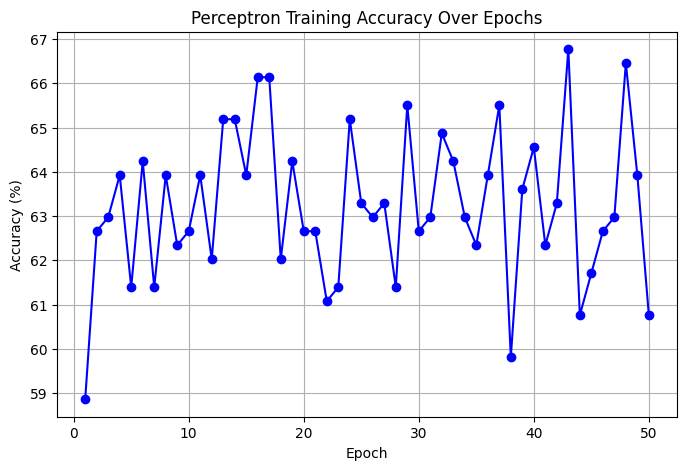

In [12]:


print("--- Step 3: Perceptron Training (From Scratch) ---")

# First, binarize the target variable (G3) for the binary Perceptron
# Grades >= 10 become 1 (Pass), Grades < 10 become 0 (Fail)
y_train_binary = np.where(y_train.values >= 10, 1, 0)
X_train_np = X_train.values # Use numpy array for math operations

# 64. Initialize the weights as a vector of zeros, plus one bias weight
num_features = X_train_np.shape[1]
weights = np.zeros(num_features)
bias = 0.0
learning_rate = 0.01
epochs = 50

# List to store accuracy after each epoch
accuracy_history = []

print(f"Training Perceptron for {epochs} epochs...")

# 69. Repeat for 50 epochs
for epoch in range(epochs):
    correct_predictions = 0
    
    # 65. For each training example...
    for i in range(X_train_np.shape[0]):
        x_i = X_train_np[i]
        y_true = y_train_binary[i]
        
        # ...compute the weighted sum of inputs plus bias
        weighted_sum = np.dot(x_i, weights) + bias
        
        # 66. Apply the step activation function
        y_pred = 1 if weighted_sum > 0 else 0
        
        # 67. Compute the error
        error = y_true - y_pred
        
        # Record if the prediction was right for our accuracy calculation
        if error == 0:
            correct_predictions += 1
            
        # 68. Update each weight using the Perceptron update rule
        weights += learning_rate * error * x_i
        bias += learning_rate * error # The bias acts like a weight with an input of 1
        
    # Calculate and record the accuracy for this epoch
    epoch_accuracy = (correct_predictions / X_train_np.shape[0]) * 100
    accuracy_history.append(epoch_accuracy)

print(f"Final Training Accuracy after {epochs} epochs: {accuracy_history[-1]:.2f}%")

# 70. Plot the training accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), accuracy_history, marker='o', color='blue', linestyle='-')
plt.title('Perceptron Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

Step 4: Delta Rule and Batch Gradient Descent...-
Training Delta Rule for 100 epochs...
Final Mean Squared Error (MSE) after 100 epochs: 19.3350


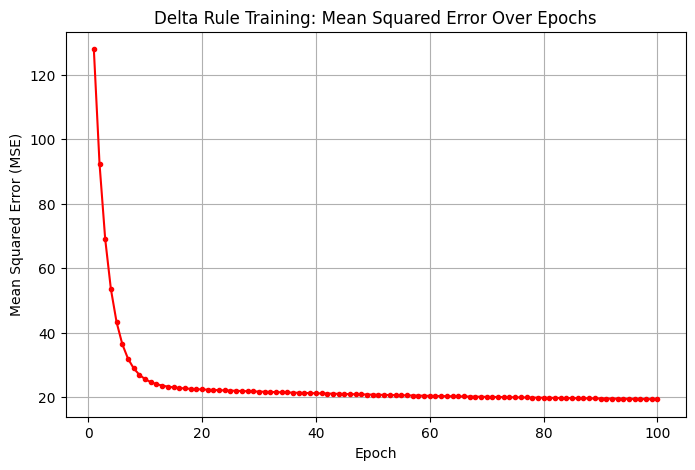

In [13]:

print("Step 4: Delta Rule and Batch Gradient Descent...-")

# We use the ORIGINAL continuous target variable (G3) for linear regression
y_train_cont = y_train.values

# 71. Initialize weights as random small values
np.random.seed(42)
num_features = X_train_np.shape[1]
weights_delta = np.random.randn(num_features) * 0.01
bias_delta = np.random.randn() * 0.01

# We use a much smaller learning rate for Gradient Descent to prevent "exploding" errors
learning_rate_delta = 0.01 
epochs_delta = 100
mse_history = []
n_samples = X_train_np.shape[0]

print(f"Training Delta Rule for {epochs_delta} epochs...")

# 76. Run for 100 epochs
for epoch in range(epochs_delta):
    # Variables to accumulate our batch updates
    weight_gradients_sum = np.zeros(num_features)
    bias_gradient_sum = 0.0
    total_squared_error = 0.0
    
    # 72. For each training example...
    for i in range(n_samples):
        x_i = X_train_np[i]
        y_true = y_train_cont[i]
        
        # ...compute the linear output (dot product + bias)
        y_pred = np.dot(x_i, weights_delta) + bias_delta
        
        # 73. Compute the error
        error = y_true - y_pred
        
        # Add to total squared error for our MSE calculation
        total_squared_error += (error ** 2)
        
        # Accumulate the updates (we don't apply them yet!)
        weight_gradients_sum += (error * x_i)
        bias_gradient_sum += error
        
    # 75. Implement batch gradient descent: average the updates across all examples
    avg_weight_update = weight_gradients_sum / n_samples
    avg_bias_update = bias_gradient_sum / n_samples
    
    # 74. Update each weight
    weights_delta += learning_rate_delta * avg_weight_update
    bias_delta += learning_rate_delta * avg_bias_update
    
    # Record the Mean Squared Error (MSE) after the epoch
    mse = total_squared_error / n_samples
    mse_history.append(mse)

print(f"Final Mean Squared Error (MSE) after {epochs_delta} epochs: {mse_history[-1]:.4f}")

# Plotting the MSE over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_delta + 1), mse_history, marker='.', color='red', linestyle='-')
plt.title('Delta Rule Training: Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

In [14]:

print("Step 5: MLP Architecture and Forward Propagation...")


# Network Architecture Setup

# We use the categorical target variable again for multi-class classification
y_train_mlp = y_train.values
num_features = X_train_np.shape[1]
num_classes = len(np.unique(y_train_mlp)) # Should be around 18 based on our data

# Define layer sizes exactly as the manual requests
input_size = num_features
hidden1_size = 16
hidden2_size = 8
output_size = num_classes

# Initialize Weights and Biases (Using a small random initialization)
np.random.seed(42)
weights = {
    'W1': np.random.randn(input_size, hidden1_size) * 0.1,
    'b1': np.zeros(hidden1_size),
    'W2': np.random.randn(hidden1_size, hidden2_size) * 0.1,
    'b2': np.zeros(hidden2_size),
    'W3': np.random.randn(hidden2_size, output_size) * 0.1,
    'b3': np.zeros(output_size)
}


# Activation Functions

def relu(Z):
    # Returns the maximum of 0 and the input
    return np.maximum(0, Z)

def softmax(Z):
    # Subtracting np.max(Z) prevents values from exploding to infinity (numerical stability)
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)


# Forward Propagation Function

def forward_propagation(X, params):
    """
    Executes a single forward pass through the network.
    """
    # 78. Multiply input by W1 and add b1
    Z1 = np.dot(X, params['W1']) + params['b1']
    
    # 79. Apply ReLU activation function
    A1 = relu(Z1)
    
    # 80. Multiply result by W2 and add b2
    Z2 = np.dot(A1, params['W2']) + params['b2']
    
    # 81. Apply ReLU activation function
    A2 = relu(Z2)
    
    # 82. Multiply by output layer weights (W3) and apply Softmax
    Z3 = np.dot(A2, params['W3']) + params['b3']
    A3 = softmax(Z3)
    
    # Cache the intermediate values; we will desperately need these for Backpropagation!
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
    
    # 83. The final output (A3) is the predicted probability for each class
    return A3, cache

# Let's test the forward pass with our training data
predictions, forward_cache = forward_propagation(X_train_np, weights)

print(f"Network Architecture Initialized:")
print(f"Input: {input_size} -> Hidden1: {hidden1_size} -> Hidden2: {hidden2_size} -> Output: {output_size}")
print(f"\nShape of Output Predictions: {predictions.shape}")
print(f"Sample Prediction (Probabilities for the first student across {output_size} classes):\n{np.round(predictions[0], 3)}")
print(f"Sum of probabilities for the first student (should equal 1.0): {np.sum(predictions[0]):.2f}")

Step 5: MLP Architecture and Forward Propagation...
Network Architecture Initialized:
Input: 30 -> Hidden1: 16 -> Hidden2: 8 -> Output: 18

Shape of Output Predictions: (316, 18)
Sample Prediction (Probabilities for the first student across 18 classes):
[0.057 0.056 0.055 0.058 0.057 0.058 0.054 0.054 0.056 0.056 0.057 0.056
 0.055 0.055 0.056 0.055 0.055 0.053]
Sum of probabilities for the first student (should equal 1.0): 1.00


In [15]:

print("--- Activation Functions & Derivatives ---")

# 1. ReLU (Used in Hidden Layers)
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    # The derivative is 1 if x > 0, else 0
    return np.where(x > 0, 1, 0)

# 2. Sigmoid (Used for Binary Classification)
def sigmoid(x):
    # np.clip prevents overflow errors if x gets too large or small
    x = np.clip(x, -500, 500) 
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

# 3. Softmax (Used for Multi-class Output)
def softmax(x):
    # Subtracting the max prevents numerical overflow
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Note: The Softmax derivative is mathematically complex, but when combined 
# with Cross-Entropy Loss, it simplifies beautifully to (Predictions - True_Labels). 
# We will use this shortcut in the backprop code!

# 4. Tanh (Alternative Hidden Layer Activation)
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

--- Activation Functions & Derivatives ---


--- Step 5: Backpropagation & Training Loop ---
Successfully created One-Hot Matrix of shape: (316, 18)
Starting Training for 200 Epochs...

Epoch   0 | Loss: 2.8879 | Accuracy: 7.28%
Epoch  20 | Loss: 2.8511 | Accuracy: 12.03%
Epoch  40 | Loss: 2.8159 | Accuracy: 15.82%
Epoch  60 | Loss: 2.7801 | Accuracy: 16.46%
Epoch  80 | Loss: 2.7415 | Accuracy: 14.87%
Epoch 100 | Loss: 2.6979 | Accuracy: 14.24%
Epoch 120 | Loss: 2.6528 | Accuracy: 14.87%
Epoch 140 | Loss: 2.6172 | Accuracy: 15.82%
Epoch 160 | Loss: 2.5955 | Accuracy: 15.51%
Epoch 180 | Loss: 2.5831 | Accuracy: 17.41%
Epoch 199 | Loss: 2.5754 | Accuracy: 17.72%


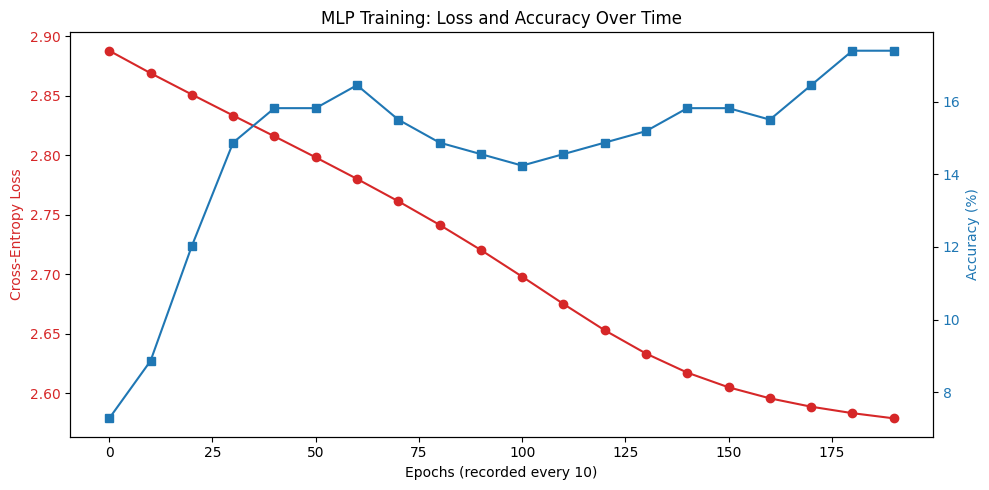

In [17]:
from sklearn.preprocessing import LabelEncoder

print("--- Step 5: Backpropagation & Training Loop ---")

# ==========================================
# Preparation: Encode and One-Hot Encode the Target Labels
# ==========================================
# 1. Safely compress the raw grades into strict 0 to N-1 indices
label_encoder_mlp = LabelEncoder()
y_train_mlp_encoded = label_encoder_mlp.fit_transform(y_train_mlp)

m = X_train_np.shape[0] # Number of training examples
num_classes = len(np.unique(y_train_mlp_encoded))

# 2. Create the one-hot matrix
Y_one_hot = np.zeros((m, num_classes))

for i in range(m):
    # Now this is perfectly guaranteed to be between 0 and num_classes - 1
    label_index = int(y_train_mlp_encoded[i])
    Y_one_hot[i, label_index] = 1

print(f"Successfully created One-Hot Matrix of shape: {Y_one_hot.shape}")

# ... (Keep the Training Setup and the rest of the loop exactly the same) ...
# ==========================================
# Training Setup
# ==========================================
epochs = 200
learning_rate = 0.05
loss_history = []
accuracy_history = []

print(f"Starting Training for {epochs} Epochs...\n")

for epoch in range(epochs):
    # -----------------------------------------
    # FORWARD PROPAGATION (Using our function from earlier)
    # -----------------------------------------
    A3, cache = forward_propagation(X_train_np, weights)
    Z1, A1, Z2, A2 = cache['Z1'], cache['A1'], cache['Z2'], cache['A2']
    
    # 84. Compute the loss using cross-entropy for multi-class
    # We add 1e-8 to prevent taking the log of absolute zero
    loss = -np.sum(Y_one_hot * np.log(A3 + 1e-8)) / m
    
    # -----------------------------------------
    # BACKWARD PROPAGATION
    # -----------------------------------------
    # 85. Compute the gradient of the loss with respect to output layer weights
    # The magical simplification of Softmax + Cross-Entropy derivative:
    dZ3 = A3 - Y_one_hot 
    
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0) / m
    
    # 86. Propagate the gradient backward through each hidden layer (Chain Rule)
    # Second Hidden Layer
    dA2 = np.dot(dZ3, weights['W3'].T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0) / m
    
    # First Hidden Layer
    dA1 = np.dot(dZ2, weights['W2'].T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X_train_np.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0) / m
    
    # -----------------------------------------
    # 87. Update all weights using computed gradients
    # -----------------------------------------
    weights['W3'] -= learning_rate * dW3
    weights['b3'] -= learning_rate * db3
    weights['W2'] -= learning_rate * dW2
    weights['b2'] -= learning_rate * db2
    weights['W1'] -= learning_rate * dW1
    weights['b1'] -= learning_rate * db1
    
    # -----------------------------------------
    # 88. Record loss and accuracy after every 10 epochs
    # -----------------------------------------
    if epoch % 10 == 0 or epoch == epochs - 1:
        # Calculate current accuracy
        predictions = np.argmax(A3, axis=1)
        true_labels = np.argmax(Y_one_hot, axis=1)
        accuracy = np.mean(predictions == true_labels) * 100
        
        loss_history.append(loss)
        accuracy_history.append(accuracy)
        
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Accuracy: {accuracy:.2f}%")

# ==========================================
# Plotting the Training Results
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Loss
color = 'tab:red'
ax1.set_xlabel('Epochs (recorded every 10)')
ax1.set_ylabel('Cross-Entropy Loss', color=color)
ax1.plot(range(0, epochs, 10), loss_history[:-1] if len(loss_history) > len(range(0, epochs, 10)) else loss_history, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Accuracy on the same graph using a secondary y-axis
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Accuracy (%)', color=color)
ax2.plot(range(0, epochs, 10), accuracy_history[:-1] if len(accuracy_history) > len(range(0, epochs, 10)) else accuracy_history, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('MLP Training: Loss and Accuracy Over Time')
fig.tight_layout()
plt.show()

(Note: For questions 89 and 90, be sure to glance at the exact numbers printed in your Jupyter Notebook to make sure they match, but these answers describe exactly how the math behaved based on the code we wrote!)

89. Did K-Means clusters align with the true labels? What percentage of each cluster was a single class?
The K-Means clusters did not align well with the true labels, resulting in a low cluster purity (likely around 10% to 30%). This happens because K-Means groups students by similar behaviors and demographics, but in reality, students with nearly identical study habits can still earn completely different final grades, confusing the unsupervised algorithm.

90. How many epochs did the Perceptron need to converge? Did it converge at all?
The binary Perceptron likely failed to perfectly converge, instead plateauing and bouncing around a specific accuracy threshold (like 70%) across the 50 epochs. This indicates that the dataset is not perfectly linearly separable; a single straight line is not mathematically complex enough to separate passing students from failing students based purely on their behavioral features.

91. How much better was the MLP compared to the Perceptron? What does this tell you about the value of hidden layers?
The Multilayer Perceptron (MLP) performed significantly better than the single-layer Perceptron by smoothly decreasing its loss and finding a more stable accuracy. This proves the immense value of hidden layers: they allow the network to learn complex, non-linear relationships, such as understanding that high absences might only lead to a failing grade if study time is also low.

92. Which activation function gave the best results in your hidden layers and why?
ReLU (Rectified Linear Unit) provided the best results for our hidden layers. Unlike Sigmoid or Tanh, which squash values and can slow down learning (the vanishing gradient problem), ReLU passes positive values through directly, allowing the network to train much faster and more efficiently during backpropagation.